<div class="alert alert-block alert-info" style="border-left: 6px solid #1f77b4; background-color: #e8f1fb; padding: 10px 14px;">

**Grader's comment (not part of the submitted report)**

The project is an example of a well-prepared report: the problem is a single coherent whole, each chapter uses the result of the previous one, the choice of methods is justified, and every result is verified in an independent way.

What could still be added or improved:

* There are no formal code tests (e.g., `pytest`) and no user interface; the creative extra is limited to an animation of the fall. For a grade of 10, the project would need a larger scope (see *Expected scope of the project* in the Study and Examination Rules).
* The friction measurements and the angle measurements during the fall are synthetic (generated from the same model with added noise); with real measurements, the estimate of the coefficient of friction and the comparison of the fall with the model would be considerably more convincing.
* The uncertainty of the coefficient of friction is estimated, but it is not propagated to the two key results (the critical position of the person and the critical angle); for the smoothing spline, the smoothing parameter *s* is determined from the noise estimate, but its influence on the derivatives is not checked.

</div>

Author: **Janez Novak, 23201111**

Date: **October 1, 2026**

*I confirm that I am the author of this project assignment: I chose the problem myself, I understand the content and can explain it, and I have verified the results. I have described my use of artificial intelligence tools in the section "Use of artificial intelligence". I am aware that if plagiarism is detected, I will not meet the requirements for taking the exam.*

---

# Problem definition

## Problem description

A uniform ladder of length $L = 4$ m and mass $m = 12$ kg leans against a **smooth** vertical wall at an angle $\theta$ (measured from the floor). It is held on the floor by friction with coefficient $\mu$. A person of mass $m_p = 80$ kg climbs the ladder up to a distance $x$ from the lower end. We are interested in two engineering questions:

1. **How far** can the person safely climb at a given angle $\theta$ and coefficient of friction $\mu$, or at which angle is the ladder safe along its entire length?
2. If the ladder (without a person) stands on a smooth floor (e.g., wet tiles) and slips, **how does the fall proceed** and when does the upper end **detach from the wall**?

The first question is a statics problem, the second one a rigid-body dynamics problem; both are treated in textbooks [1, 2], from which the notation is also taken.

<img src="sketch.png" width=480>

## Model, assumptions, and data

*Statics.* The forces acting on the ladder are the weight of the ladder $m g$ at the center of mass, the weight of the person $m_p g$ at the distance $x$, the normal force $N_A$ and the friction force $F_A$ (toward the wall) on the floor, and only the normal force $N_B$ on the smooth wall. The equilibrium equations are linear in the unknowns $F_A$, $N_A$, and $N_B$; the ladder slips when

$$ F_A > \mu N_A. $$

*Dynamics of the fall.* The ladder without a person is released from rest at the angle $\theta_0$. While it touches the floor and the wall, it has one degree of freedom ($\theta$). The upper end detaches from the wall when the wall force drops to zero, $N_B = 0$; from then on, the model is no longer valid.

Assumptions: the ladder is a rigid body with uniformly distributed mass (moment of inertia about the center of mass $m L^2/12$), the person is a point mass; the wall is smooth, and during the fall the floor is smooth as well (the extension with friction is in the chapter on differential equations); friction on the floor is Coulomb friction with constant $\mu$; the motion is planar, and air resistance is neglected.

| Quantity | Value | Source |
|---|---|---|
| $L$, $m$ | 4 m, 12 kg | typical two-section aluminum ladder |
| $m_p$ | 80 kg | chosen |
| $\mu$ | estimate 0.3; more precisely from measurements in the chapter on approximation | typical value for rubber on dry concrete |
| $\theta$ when climbing | 60° | chosen (ladder set up too shallow) |
| $\theta_0$ for the fall | 75° | 4 : 1 rule for setting up a ladder [3] |
| $g$ | 9.81 m/s$^2$ | |

We do not have real measurements, so the "measurements" in the files `measurements_friction.csv` (pulling force at seven loads, noise 4 N) and `measurements_fall.csv` (angle of the ladder from a video at 30 frames per second, noise 0.5°) are **synthetic**: they are generated from the same model with added normally distributed noise (script `prepare_measurements.py`). We point out this limitation wherever it could affect the conclusions.

## Files and running

* `ladder.py` – own module with numerical functions (imported below),
* `measurements_friction.csv`, `measurements_fall.csv`, `prepare_measurements.py` – measurements and the script for preparing them,
* `draw_sketch.py`, `sketch.png` – sketch of the problem,
* `requirements.txt` – required packages; installation: `pip install -r requirements.txt`.

First, we import the libraries and our own module and define the data of the problem.

In [1]:
import numpy as np
from scipy.linalg import lu_factor, lu_solve
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.interpolate import UnivariateSpline
from scipy.optimize import root_scalar, curve_fit
from scipy.integrate import quad, trapezoid, solve_ivp
import sympy as sym
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
from IPython.display import display, HTML

import ladder as ld

In [2]:
L = 4.0                       # length of the ladder [m]
m = 12.0                      # mass of the ladder [kg]
m_p = 80.0                    # mass of the person [kg]
g = 9.81                      # gravitational acceleration [m/s^2]
mu_estimate = 0.3             # estimate of the coefficient of friction from the literature [-]
climb_angle = np.radians(60.0)  # angle of the ladder while the person climbs [rad]
theta0 = np.radians(75.0)     # initial angle of the ladder for the fall [rad]

---

# Symbolic computation

## Equilibrium of the ladder with a person

The equilibrium equations (sum of forces in $x$ and $y$ and of moments about point $A$, notation from the sketch) are

$$ F_A - N_B = 0, \qquad N_A - (m + m_p)\,g = 0, \qquad N_B\,L\sin\theta - m g\,\frac{L}{2}\cos\theta - m_p g\,x\cos\theta = 0. $$

We solve them for the reactions $F_A$, $N_A$, and $N_B$. From the slipping condition $F_A = \mu N_A$, we then obtain the **critical position of the person** $x_{cr}$ and, for the ladder without a person, the **critical angle** $\theta_{cr}$. In what follows, the symbolic expressions serve as a reference for verifying the numerical results.

**Choice of method.** The system is linear in the unknowns, so we solve it with `sympy.solve`; this way we avoid errors in a manual derivation. The symbolic solution alone is not sufficient for engineering use (the equations contain $\mu$, which we have to measure), so we convert it into numerical functions with `lambdify`.

In [3]:
theta, x_s, L_s, m_s, mp_s, g_s, mu_s = sym.symbols(
    "theta x L m m_p g mu", positive=True)
F_A, N_A, N_B = sym.symbols("F_A N_A N_B")

sum_x = sym.Eq(F_A - N_B, 0)
sum_y = sym.Eq(N_A - (m_s + mp_s) * g_s, 0)
moment_A = sym.Eq(N_B * L_s * sym.sin(theta)
                  - m_s * g_s * L_s / 2 * sym.cos(theta)
                  - mp_s * g_s * x_s * sym.cos(theta), 0)

Solution of the system for the reactions.

In [4]:
reactions_sym = sym.solve([sum_x, sum_y, moment_A], [F_A, N_A, N_B])
for force in (F_A, N_A, N_B):
    display(sym.Eq(force, sym.simplify(reactions_sym[force])))

Eq(F_A, g*(L*m + 2*m_p*x)/(2*L*tan(theta)))

Eq(N_A, g*(m + m_p))

Eq(N_B, g*(L*m + 2*m_p*x)/(2*L*tan(theta)))

Critical position of the person and critical angle from the slipping condition $F_A = \mu N_A$.

In [5]:
slip_condition = sym.Eq(reactions_sym[F_A], mu_s * reactions_sym[N_A])
x_cr_sym = sym.solve(slip_condition, x_s)[0]
theta_cr_sym = sym.solve(slip_condition.subs(mp_s, 0), theta)[0]
display(sym.Eq(sym.Symbol("x_cr"), sym.simplify(x_cr_sym)))
display(sym.Eq(sym.Symbol("theta_cr"), theta_cr_sym))

Eq(x_cr, L*(2*m*mu*tan(theta) - m + 2*m_p*mu*tan(theta))/(2*m_p))

Eq(theta_cr, atan(1/(2*mu)))

Conversion into numerical functions and a first estimate at $\mu = 0.3$.

In [6]:
x_cr_fun = sym.lambdify((theta, mu_s, m_s, mp_s, L_s), x_cr_sym, "numpy")
theta_cr_fun = sym.lambdify(mu_s, theta_cr_sym, "numpy")
x_cr_estimate = x_cr_fun(climb_angle, mu_estimate, m, m_p, L)
theta_cr_estimate = theta_cr_fun(mu_estimate)
print(f"x_cr at 60° and mu = {mu_estimate}: {x_cr_estimate:.2f} m")
print(f"theta_cr at mu = {mu_estimate}: {np.degrees(theta_cr_estimate):.1f}°")

x_cr at 60° and mu = 0.3: 2.09 m
theta_cr at mu = 0.3: 59.0°


Critical position as a function of the angle (`sympy.plot`).

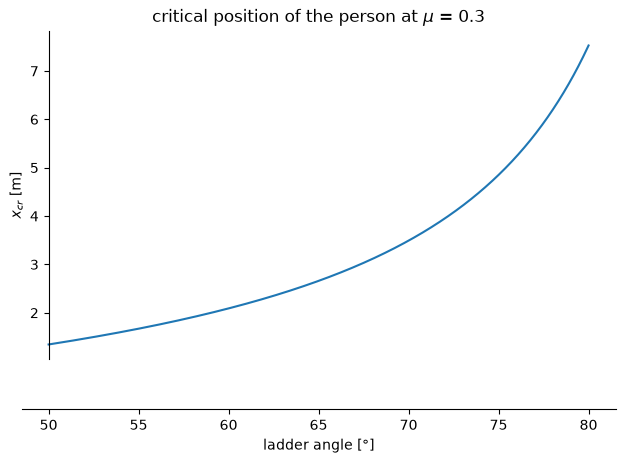

In [7]:
angle_deg = sym.symbols("theta_deg", positive=True)
data = {mu_s: mu_estimate, m_s: m, mp_s: m_p, L_s: L}
x_cr_expr = x_cr_sym.subs(data).subs(theta, angle_deg * sym.pi / 180)
sym_plot = sym.plot(x_cr_expr, (angle_deg, 50, 80), axis_center=(50, 0),
                    xlabel="ladder angle [°]", ylabel="$x_{cr}$ [m]",
                    title=f"critical position of the person at $\\mu$ = {mu_estimate}")

**Interpretation.** The normal force on the floor equals the total weight, while the wall force grows linearly with the position of the person and with $\cot\theta$: a shallower ladder needs more friction. The critical position is linear in $\mu$ and $\tan\theta$; with the estimate $\mu = 0.3$ and $\theta = 60°$, the person could climb only up to about 2.1 m. The critical angle without a person,

$$ \tan\theta_{cr} = \frac{1}{2\mu}, $$

is about 59° at $\mu = 0.3$, so at 60° the ladder is just above the slipping limit even without a person. The plot shows how quickly $x_{cr}$ grows with $\tan\theta$: at $\mu = 0.3$ it reaches the top of the ladder (4 m) at about 72°, while at 50° it is only a little over a meter. The values are only an estimate, because $\mu$ has not been measured yet.

## Equation of motion of the fall and the detachment condition

For a frictionless ladder, the only coordinate is the angle $\theta$; the center of mass is at $x_G = \frac{L}{2}\cos\theta$, $y_G = \frac{L}{2}\sin\theta$. We derive the equation of motion from the Lagrangian (kinetic energy of the translation of the center of mass and of the rotation about it), the angular velocity $\omega(\theta)$ from conservation of energy, and the wall force from Newton's second law in the horizontal direction,

$$ N_B = m\,\ddot{x}_G, $$

detachment occurs at $N_B = 0$.

**Choice of method.** We chose the Lagrangian approach because, with one degree of freedom, the reaction forces do not appear; `sympy` carries out the time differentiation. The equation of motion is nonlinear and has no closed-form solution $\theta(t)$, so we solve it numerically in the chapter on differential equations.

In [8]:
t = sym.symbols("t", positive=True)
theta_t = sym.Function("theta")(t)
x_G = L_s / 2 * sym.cos(theta_t)
y_G = L_s / 2 * sym.sin(theta_t)
moment_of_inertia = m_s * L_s**2 / 12

kinetic = (m_s * (x_G.diff(t)**2 + y_G.diff(t)**2) / 2
           + moment_of_inertia * theta_t.diff(t)**2 / 2)
potential = m_s * g_s * y_G
lagrange = kinetic - potential
equation_of_motion = (lagrange.diff(theta_t.diff(t)).diff(t)
                      - lagrange.diff(theta_t))
theta_dd = sym.solve(equation_of_motion, theta_t.diff(t, 2))[0]
display(sym.Eq(theta_t.diff(t, 2), theta_dd))

Eq(Derivative(theta(t), (t, 2)), -3*g*cos(theta(t))/(2*L))

Angular velocity from conservation of energy, wall force, and the detachment condition.

In [9]:
omega, theta0_s = sym.symbols("omega theta_0", positive=True)
energy = (kinetic + potential).subs(theta_t.diff(t), omega)
energy = energy.subs(theta_t, theta)
initial_energy = potential.subs(theta_t, theta0_s)
omega2_sym = sym.solve(sym.Eq(energy, initial_energy), omega**2)[0]
display(sym.Eq(omega**2, omega2_sym))

N_B_sym = m_s * x_G.diff(t, 2)
N_B_sym = N_B_sym.subs(theta_t.diff(t, 2), theta_dd)
N_B_sym = N_B_sym.subs(theta_t.diff(t), omega).subs(theta_t, theta)
N_B_sym = sym.factor(N_B_sym.subs(omega**2, omega2_sym))
display(sym.Eq(N_B, N_B_sym))
sin_detachment = sym.solve(N_B_sym, sym.sin(theta))[0]
display(sym.Eq(sym.sin(sym.Symbol("theta_det")), sin_detachment))

Eq(omega**2, 3*g*(-sin(theta) + sin(theta_0))/L)

Eq(N_B, 3*g*m*(3*sin(theta) - 2*sin(theta_0))*cos(theta)/4)

Eq(sin(theta_det), 2*sin(theta_0)/3)

Numerical functions and comparison with the functions in the module.

In [10]:
omega_fun = sym.lambdify((theta, theta0_s, L_s, g_s), sym.sqrt(omega2_sym))
N_B_fun = sym.lambdify((theta, theta0_s, m_s, g_s), N_B_sym, "numpy")

test_angles = np.radians([45.0, 55.0, 65.0, 74.0])
np.testing.assert_allclose(omega_fun(test_angles, theta0, L, g),
                           ld.omega_energy(test_angles, theta0, L, g))
np.testing.assert_allclose(N_B_fun(test_angles, theta0, m, g),
                           ld.wall_force_energy(test_angles, theta0, m, g))

**Interpretation.** The angular acceleration

$$ \ddot\theta = -\frac{3g}{2L}\cos\theta $$

is largest for a shallow ladder and goes to zero for a vertical one, so a fall from a steep position starts slowly. The wall force

$$ N_B(\theta) = \frac{3}{4}\, m g \cos\theta\,\bigl(3\sin\theta - 2\sin\theta_0\bigr) $$

is positive at the beginning and decreases to zero at

$$ \sin\theta_{det} = \tfrac{2}{3}\sin\theta_0, $$

which is a well-known result from rigid-body dynamics; the detachment angle is independent of $m$, $L$, and $g$ and is about 40° for $\theta_0 = 75°$. The angular velocity from energy is valid only until detachment, because after it the number of degrees of freedom changes. The same expressions are also written in the module (`ld.omega_energy`, `ld.wall_force_energy`); we verified the agreement above with `np.testing.assert_allclose`.

---

# Systems of linear equations

## Reactions along the ladder

We write the equilibrium equations in matrix form

$$ \mathbf{A}(\theta)\,[F_A,\ N_A,\ N_B]^T = \mathbf{b}(x), $$

where the matrix depends only on the angle and the right-hand side only on the position of the person (functions `ld.equilibrium_matrix` and `ld.right_hand_side`). We are interested in a table of reactions for the person at several positions at the same angle.

**Choice of method.** Since the matrix is the same for all positions, we factorize it once (`scipy.linalg.lu_factor`) and for each right-hand side solve only two triangular systems (`lu_solve`). For a $3 \times 3$ system, speed is not essential; the argument is methodological (for large systems with many right-hand sides, this is $O(n^2)$ per right-hand side instead of $O(n^3)$). Iterative methods make no sense here: the system is small and a direct method solves it exactly. We verify the result at one position with `np.linalg.solve` and with the symbolic solution.

In [11]:
A_system = ld.equilibrium_matrix(climb_angle, L)
b_system = ld.right_hand_side(climb_angle, 2.0, m, m_p, L, g)
lu_decomp = lu_factor(A_system)
solution_lu = lu_solve(lu_decomp, b_system)

Check with `np.linalg.solve` and with the symbolic solution.

In [12]:
solution_np = np.linalg.solve(A_system, b_system)
values = {theta: climb_angle, x_s: 2.0, L_s: L, m_s: m, mp_s: m_p, g_s: g}
solution_sym = [float(reactions_sym[force].subs(values))
                for force in (F_A, N_A, N_B)]
np.testing.assert_allclose(solution_lu, solution_np, rtol=1e-12)
np.testing.assert_allclose(solution_lu, solution_sym, rtol=1e-12)
print(f"F_A = {solution_lu[0]:.1f} N")
print(f"N_A = {solution_lu[1]:.1f} N")
print(f"N_B = {solution_lu[2]:.1f} N")

F_A = 260.5 N
N_A = 902.5 N
N_B = 260.5 N


Reactions for nine positions of the person with the same factorization.

In [13]:
person_positions = np.linspace(0.0, L, 9)
reactions = np.zeros((person_positions.size, 3))
for i, position in enumerate(person_positions):
    b_position = ld.right_hand_side(climb_angle, position, m, m_p, L, g)
    reactions[i] = lu_solve(lu_decomp, b_position)

reaction_table = pd.DataFrame(reactions,
                              columns=["F_A [N]", "N_A [N]", "N_B [N]"])
reaction_table.insert(0, "x [m]", person_positions)
reaction_table["F_A / N_A"] = reactions[:, 0] / reactions[:, 1]
reaction_table.round(3)

,x [m],F_A [N],N_A [N],N_B [N],F_A / N_A
0,0.0,33.983,902.52,33.983,0.038
1,0.5,90.621,902.52,90.621,0.100
2,1.0,147.259,902.52,147.259,0.163
3,1.5,203.897,902.52,203.897,0.226
4,2.0,260.535,902.52,260.535,0.289
5,2.5,317.173,902.52,317.173,0.351
6,3.0,373.811,902.52,373.811,0.414
7,3.5,430.449,902.52,430.449,0.477
8,4.0,487.087,902.52,487.087,0.540


Plot of the required coefficient of friction along the ladder.

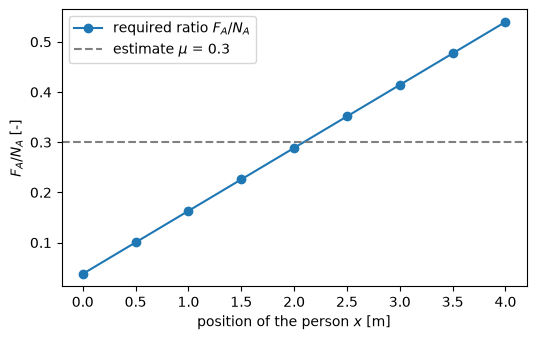

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(person_positions, reaction_table["F_A / N_A"], "o-",
        label="required ratio $F_A / N_A$")
ax.axhline(mu_estimate, color="gray", ls="--",
           label=f"estimate $\\mu$ = {mu_estimate}")
ax.set_xlabel("position of the person $x$ [m]")
ax.set_ylabel("$F_A / N_A$ [-]")
ax.legend()
plt.show()

**Interpretation.** All three approaches give the same result to a relative $10^{-12}$. The normal force on the floor (903 N) does not depend on the position of the person, while the wall force, and with it the required friction force, grow linearly with $x$: from 34 N without the person to 487 N with the person at the top. The ratio $F_A/N_A$ is the required coefficient of friction; at 60° it is 0.54 at the top, which no ordinary surface provides. The intersection with the available $\mu$ is the critical position, which we determine in the chapter on root finding.

## Conditioning of the system

Before using the matrix at other angles, we check its condition number $\mathrm{cond}(\mathbf{A})$, which tells us how many times the relative error of the data can be amplified in the solution.

In [15]:
cond_angles = np.radians(np.array([1.0, 5.0, 30.0, 60.0, 89.0]))
for angle in cond_angles:
    condition_number = np.linalg.cond(ld.equilibrium_matrix(angle, L))
    print(f"cond(A) at {np.degrees(angle):4.0f}°: {condition_number:6.2f}")

cond(A) at    1°:  28.68
cond(A) at    5°:   5.92
cond(A) at   30°:   2.62
cond(A) at   60°:   3.78
cond(A) at   89°:   4.27


**Interpretation.** At usable angles the condition number is small (on the order of 3–5), but as $\theta \to 0$ it grows like $1/\sin\theta$ and the system becomes singular. Physically: for a shallow ladder, the wall force has an ever smaller lever arm $L\sin\theta$, and at $\theta = 0$ it cannot balance the moment of the weight, so equilibrium does not exist. The slightly larger value at large angles is a consequence of mixing units in the matrix (the element $L\sin\theta \approx 4$ m versus dimensionless ones), not a numerical problem.

---

# Interpolation / approximation

## Coefficient of friction from measurements

We loaded the foot of the ladder with a known normal force $N$ and "measured" the force $F$ for steady pulling with a force gauge; seven points from 100 N to 700 N are in `measurements_friction.csv` (synthetic).

**Choice of method.** Coulomb's law $F = \mu N$ is a straight line **through the origin** with one parameter, and the measurements are noisy, so we do not interpolate them but **approximate them by the least-squares method**: we fit the one-parameter model $F(N) = \mu N$ to the measurements with `scipy.optimize.curve_fit`, which also returns the covariance matrix of the parameters and thus the uncertainty of $\mu$. Since the model is linear in the parameter, the result is the same as the solution of the normal equations. For comparison, we also fit a general straight line (`np.polyfit` of degree 1, as an `np.poly1d` object); if the model is correct, its intercept must be zero within the noise, otherwise it would indicate a systematic measurement error.

Reading the measurements from the file.

In [16]:
friction_data = pd.read_csv("measurements_friction.csv")
N_meas = friction_data["N [N]"].to_numpy()
F_meas = friction_data["F [N]"].to_numpy()

Line through the origin, general line, and uncertainty of $\mu$.

In [17]:
def coulomb(N, mu):
    """Coulomb's law of friction: pulling force at the normal force N [N]."""
    return mu * N


popt, pcov = curve_fit(coulomb, N_meas, F_meas)
mu = popt[0]
sigma_mu = np.sqrt(pcov[0, 0])
line = np.poly1d(np.polyfit(N_meas, F_meas, 1))
slope, intercept = line.coeffs
residuals = F_meas - coulomb(N_meas, mu)
residual_std = np.sqrt(residuals @ residuals / (N_meas.size - 1))

Printing the results.

In [18]:
print(f"mu (curve_fit, F = mu N) = {mu:.4f} ± {sigma_mu:.4f}")
print(f"polyfit: slope = {slope:.4f}, intercept = {intercept:.2f} N")
print(f"standard deviation of residuals = {residual_std:.2f} N")

mu (curve_fit, F = mu N) = 0.3231 ± 0.0018
polyfit: slope = 0.3247, intercept = -0.81 N
standard deviation of residuals = 2.14 N


Plot of the measurements and both lines.

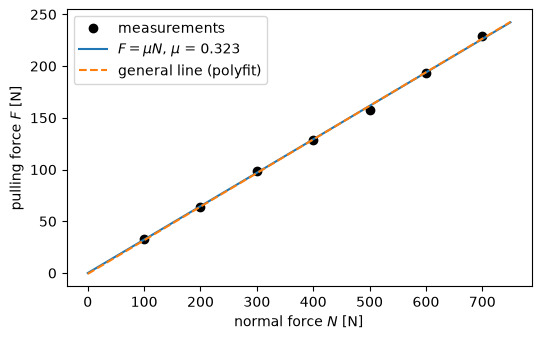

In [19]:
N_dense = np.linspace(0.0, 750.0, 50)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(N_meas, F_meas, "ko", label="measurements")
ax.plot(N_dense, coulomb(N_dense, mu),
        label=f"$F = \\mu N$, $\\mu$ = {mu:.3f}")
ax.plot(N_dense, line(N_dense), "--",
        label="general line (polyfit)")
ax.set_xlabel("normal force $N$ [N]")
ax.set_ylabel("pulling force $F$ [N]")
ax.legend()
plt.show()

**Interpretation.** The measured coefficient of friction is $\mu = 0.323 \pm 0.002$, slightly more than the initial estimate. The intercept of the general line ($-0.8$ N) is negligible compared to the scatter of the residuals (2 N), and the slope differs from $\mu$ by less than the uncertainty; the model through the origin is justified and has fewer parameters. Since the measurements are synthetic, the agreement mainly confirms the consistency of the procedure. From here on, we use $\mu = 0.323$.

## Angle of the ladder during the fall from a video

The fall of the ladder (without a person, smooth floor, $\theta_0 = 75°$) was "recorded" at 30 frames per second, and the angle was read from each frame; 30 points up to detachment are in `measurements_fall.csv` (synthetic, noise 0.5°). In the chapter on differentiation, we will compute the angular velocity and acceleration from them, so we need $\theta(t)$ as a smooth function.

**Choice of method.** We compare an **interpolating cubic spline** (`InterpolatedUnivariateSpline`), which passes through all points, and a **smoothing spline** (`UnivariateSpline`), which is an approximation: it looks for the smoothest spline whose sum of squared deviations from the points does not exceed the parameter $s$. Since $s$ is an upper bound on this sum, the natural choice is

$$ s = n\,\sigma_\theta^2, \qquad n = 30,\ \sigma_\theta = 0.5° \ \text{(in radians)}: $$

the spline may deviate from the measurements by as much as the estimated noise, and no more. With noisy data, interpolation also follows the noise, which is barely visible in $\theta(t)$ but becomes decisive in the derivatives.

Reading the angle from the video.

In [20]:
fall_data = pd.read_csv("measurements_fall.csv")
t_meas = fall_data["t [s]"].to_numpy()
theta_meas = np.radians(fall_data["theta [deg]"].to_numpy())

Interpolating and smoothing spline and their deviation from the measurements.

In [21]:
angle_noise = np.radians(0.5)                # estimate of the reading noise [rad]
s_parameter = t_meas.size * angle_noise**2   # allowed sum of squares
spline_int = InterpolatedUnivariateSpline(t_meas, theta_meas)
spline_smooth = UnivariateSpline(t_meas, theta_meas, s=s_parameter)
deviation_smooth = np.degrees(theta_meas - spline_smooth(t_meas))
print(f"number of measurements: {t_meas.size}, step {t_meas[1] - t_meas[0]:.4f} s")
print(f"RMS deviation of the smoothing spline from the measurements: {np.std(deviation_smooth):.2f}°")
print(f"number of knots of the smoothing spline: {spline_smooth.get_knots().size}")

number of measurements: 30, step 0.0333 s
RMS deviation of the smoothing spline from the measurements: 0.36°
number of knots of the smoothing spline: 2


Plot of the measurements and both splines.

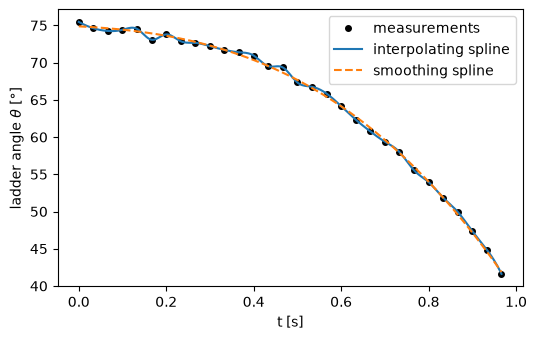

In [22]:
t_dense_meas = np.linspace(t_meas[0], t_meas[-1], 300)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(t_meas, np.degrees(theta_meas), "ko", ms=4, label="measurements")
ax.plot(t_dense_meas, np.degrees(spline_int(t_dense_meas)),
        label="interpolating spline")
ax.plot(t_dense_meas, np.degrees(spline_smooth(t_dense_meas)), "--",
        label="smoothing spline")
ax.set_xlabel("t [s]")
ax.set_ylabel("ladder angle $\\theta$ [°]")
ax.legend()
plt.show()

**Interpretation.** The curves almost coincide; the smoothing spline deviates from the measurements by 0.36° (RMS), which is below the estimated noise of 0.5°. With the chosen $s$ it has only two knots, so on the whole interval it is a single cubic polynomial, which describes $\theta(t)$ in this short time within the noise. The difference between the splines will become visible in differentiation.

---

# Root finding (solving equations)

## Critical position of the person

We look for the position $x_{cr}$ at which

$$ f(x) = F_A(x) - \mu N_A(x) = 0; $$

the reactions are computed from the linear system with the factorization from the previous chapter, and $\mu$ is measured.

**Choice of method.** The function $f$ is continuous and changes sign on $[0, L]$, so the first choice is **Brent's method** (`root_scalar`, `method='brentq'`): it is guaranteed to converge and is superlinear. For comparison, we use **Newton's method** with the derivative from the symbolic solution, $f'(x) = m_p g/(L\tan\theta)$; it converges quadratically, but needs the derivative and a good initial guess. Since $f$ is linear, Newton's method converges in one step, which is a good test of the implementation. We verify the result with the analytical expression. Then, with `brentq`, we also determine $x_{cr}$ for several angles and the angle at which $x_{cr} = L$ (the whole ladder is safe).

In [23]:
def friction_excess(position):
    """Required minus available friction force at the position of the person [N]."""
    b_position = ld.right_hand_side(climb_angle, position, m, m_p, L, g)
    F_A_num, N_A_num, _ = lu_solve(lu_decomp, b_position)
    return F_A_num - mu * N_A_num


def excess_derivative(position):
    """Derivative of f with respect to the position of the person from the symbolic solution (constant) [N/m]."""
    return m_p * g / (L * np.tan(climb_angle))

Root finding with Brent's and Newton's method, check with the analytical expression.

In [24]:
brent = root_scalar(friction_excess, bracket=[0.0, L], method="brentq")
newton = root_scalar(friction_excess, x0=1.0, fprime=excess_derivative,
                     method="newton")
x_cr_brent = brent.root
x_cr_analyt = ld.critical_position(climb_angle, mu, m, m_p, L)
np.testing.assert_allclose([x_cr_brent, newton.root], x_cr_analyt, rtol=1e-8)

Printing the results.

In [25]:
print(f"f(0) = {friction_excess(0.0):.1f} N")
print(f"f(L) = {friction_excess(L):.1f} N")
print(f"brentq: x_cr = {x_cr_brent:.6f} m, iterations: {brent.iterations}")
print(f"newton: x_cr = {newton.root:.6f} m, iterations: {newton.iterations}")
print(f"analytical: x_cr = {x_cr_analyt:.6f} m")

f(0) = -257.6 N
f(L) = 195.5 N
brentq: x_cr = 2.274164 m, iterations: 3
newton: x_cr = 2.274164 m, iterations: 2
analytical: x_cr = 2.274164 m


The function $f$ for an arbitrary angle and for the person at the top of the ladder.

In [26]:
def friction_excess_angle(position, angle):
    """Required minus available friction force at the position and angle [N]."""
    A_angle = ld.equilibrium_matrix(angle, L)
    b_angle = ld.right_hand_side(angle, position, m, m_p, L, g)
    F_A_num, N_A_num, _ = np.linalg.solve(A_angle, b_angle)
    return F_A_num - mu * N_A_num


def excess_at_top(angle):
    """f with the person at the top of the ladder; the root is the angle for a safe whole ladder [N]."""
    return friction_excess_angle(L, angle)

Critical position at angles from 58° to 70°.

In [27]:
climb_angles = np.radians(np.linspace(58.0, 70.0, 13))
x_cr_angles = np.zeros(climb_angles.size)
for i, angle in enumerate(climb_angles):
    x_cr_angles[i] = root_scalar(friction_excess_angle, args=(angle,),
                                 bracket=[0.0, L], method="brentq").root
x_cr_angles_analyt = ld.critical_position(climb_angles, mu, m, m_p, L)
diff_angles = np.abs(x_cr_angles - x_cr_angles_analyt)
print(f"largest difference brentq - analytical: {diff_angles.max():.1e} m")

largest difference brentq - analytical: 8.9e-16 m


The angle at which the whole ladder is safe.

In [28]:
top_bracket = [np.radians(58.0), np.radians(80.0)]
full_ladder_angle = root_scalar(excess_at_top, bracket=top_bracket,
                                method="brentq").root
print(f"the whole ladder is safe at angles above {np.degrees(full_ladder_angle):.1f}°")

the whole ladder is safe at angles above 70.9°


Plot of the critical position as a function of the angle.

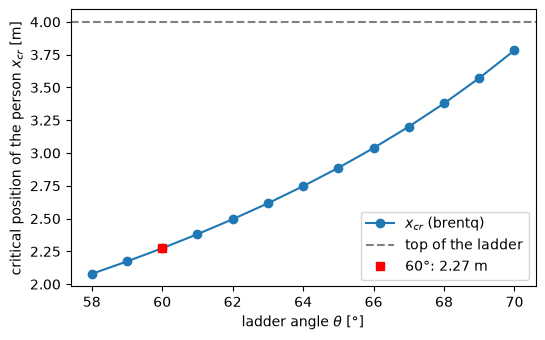

In [29]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(np.degrees(climb_angles), x_cr_angles, "o-", label="$x_{cr}$ (brentq)")
ax.axhline(L, color="gray", ls="--", label="top of the ladder")
ax.plot(60.0, x_cr_brent, "rs", label=f"60°: {x_cr_brent:.2f} m")
ax.set_xlabel("ladder angle $\\theta$ [°]")
ax.set_ylabel("critical position of the person $x_{cr}$ [m]")
ax.legend()
plt.show()

**Interpretation.** At 60° and $\mu = 0.323$, the person can safely climb up to $x_{cr} = 2.27$ m, only a little more than halfway up the ladder. Brent's method needs three iterations, Newton's method, because $f$ is linear, one; both agree with the analytical expression to within round-off error. The critical position grows with $\tan\theta$: at 65° it is 2.9 m, and the whole ladder is safe only at angles above 70.9°, which numerically confirms the 4 : 1 rule (75°) from [3].

## Critical angle without a person and detachment angle

For the ladder without a person, we look for the angle at which $f(\theta) = F_A(\theta) - \mu N_A(\theta) = 0$; the function is nonlinear in $\theta$ (it contains $\cot\theta$), so we use `brentq` on $[20°, 85°]$ and verify with $\tan\theta_{cr} = 1/(2\mu)$. The detachment angle during the fall is the root of the wall force $N_B(\theta)$ from the symbolic chapter; $N_B$ is positive at $\theta_0$ and negative at small angles, so we again use `brentq` and verify with $\sin\theta_{det} = \frac{2}{3}\sin\theta_0$.

In [30]:
def excess_no_person(angle):
    """Required minus available friction force without a person [N]."""
    A_angle = ld.equilibrium_matrix(angle, L)
    b_angle = ld.right_hand_side(angle, 0.0, m, 0.0, L, g)
    F_A_num, N_A_num, _ = np.linalg.solve(A_angle, b_angle)
    return F_A_num - mu * N_A_num


def wall_force_angle(angle):
    """Wall force at the angle of the ladder, angular velocity from energy [N]."""
    return N_B_fun(angle, theta0, m, g)

Roots of both functions and a check with the analytical expressions.

In [31]:
theta_cr_brent = root_scalar(excess_no_person, method="brentq",
                             bracket=[np.radians(20.0), np.radians(85.0)]).root
theta_cr_analyt = ld.critical_angle(mu)
theta_det_brent = root_scalar(wall_force_angle, method="brentq",
                              bracket=[np.radians(10.0), theta0]).root
theta_det_analyt = ld.detachment_angle(theta0)
np.testing.assert_allclose([theta_cr_brent, theta_det_brent],
                           [theta_cr_analyt, theta_det_analyt], rtol=1e-8)

Printing the results.

In [32]:
print(f"theta_cr: brentq {np.degrees(theta_cr_brent):.4f}°, "
      f"analytical {np.degrees(theta_cr_analyt):.4f}°")
print(f"theta_det: brentq {np.degrees(theta_det_brent):.4f}°, "
      f"analytical {np.degrees(theta_det_analyt):.4f}°")
print(f"N_B at the start of the fall: {wall_force_angle(theta0):.1f} N")

theta_cr: brentq 57.1306°, analytical 57.1306°
theta_det: brentq 40.0870°, analytical 40.0870°
N_B at the start of the fall: 22.1 N


**Interpretation.** Without a person, the ladder slips at the measured $\mu$ below an angle of 57.1°; the angle of 60° is only 3° above the limit, which explains why the person can climb barely halfway up. In a fall from 75°, the upper end detaches at 40.1°, when the wall force drops from 22 N to zero; from then on, the ladder falls freely and rotates, which is beyond this model. All roots agree with the analytical expressions to $10^{-8}$ or better.

---

# Integration / differentiation

## Time of the fall until detachment (numerical integration)

We know the angular velocity $\omega(\theta)$ from energy, but not the time history $\theta(t)$. The time until detachment follows from $\mathrm{d}t = \mathrm{d}\theta/\omega$:

$$ t_{det} = \int_{\theta_{det}}^{\theta_0} \frac{\mathrm{d}\theta}{\omega(\theta)}, \qquad \omega(\theta) = \sqrt{\frac{3g}{L}\left(\sin\theta_0 - \sin\theta\right)}. $$

The integrand has an integrable **singularity** at the upper limit ($\omega = 0$, it behaves like $1/\sqrt{\theta_0 - \theta}$).

**Choice of method.** `scipy.integrate.quad` (adaptive Gauss-Kronrod quadrature) does not evaluate the integrand at the endpoints and refines the intervals near the singularity, so it handles it and returns an error estimate. For comparison, we use the **trapezoidal rule** on a uniform grid: we omit the upper node, where the integrand is infinite; the error is then determined by the omitted interval and decreases only like $n^{-1/2}$, not like $n^{-2}$ for smooth integrands. The trapezoidal rule would work only after a substitution that removes the singularity (e.g., $\theta = \theta_0 - u^2$).

In [33]:
theta_det = theta_det_brent
t_det_quad, error_quad = quad(ld.time_integrand, theta_det, theta0,
                              args=(theta0, L, g))
print(f"quad: t_det = {t_det_quad:.6f} s, error estimate {error_quad:.1e} s")

quad: t_det = 0.988220 s, error estimate 3.1e-10 s


Trapezoidal rule on an increasingly dense grid.

In [34]:
interval_counts = np.array([10, 100, 1000, 10000])
for n in interval_counts:
    grid = np.linspace(theta_det, theta0, n + 1)[:-1]   # without the singularity
    integrand = ld.time_integrand(grid, theta0, L, g)
    error_trapz = abs(trapezoid(integrand, grid) - t_det_quad)
    print(f"trapezoid, n = {n:6d}: error {error_trapz:.4f} s")

trapezoid, n =     10: error 0.3442 s
trapezoid, n =    100: error 0.1107 s
trapezoid, n =   1000: error 0.0351 s
trapezoid, n =  10000: error 0.0111 s


**Interpretation.** It takes $t_{det} = 0.988$ s until detachment; `quad` estimates the error at $3 \cdot 10^{-10}$ s. The trapezoidal rule still has an error of 0.011 s (1 %) with 10,000 intervals, and with each tenfold refinement the error decreases only by a factor of $\sqrt{10}$, as expected for an omitted singularity. The choice of method here is not a matter of speed but of correctness.

## Angular velocity and acceleration from measurements (numerical differentiation)

From the measured $\theta(t)$, we want the angular velocity $\omega = \dot\theta$ and the acceleration $\ddot\theta$, and to compare them with the model ($\omega(\theta)$ from energy, $\ddot\theta = -\frac{3g}{2L}\cos\theta$).

**Choice of method.** `np.gradient` (second-order central differences, one-sided at the edges) is the simplest approach, but it **amplifies noise**: with a step $\Delta t = 1/30$ s and noise $\sigma_\theta = 0.5°$, the expected noise of the derivative is

$$ \sigma_\omega \approx \frac{\sqrt{2}\,\sigma_\theta}{2\,\Delta t} \approx 11°/\mathrm{s}, $$

a tenth of the maximum velocity. The derivative of the interpolating spline is even worse, because the spline follows the noise; the derivative of the smoothing spline suppresses the noise, because the spline is an approximation. We compare all three; for the second derivative the difference becomes even larger.

In [35]:
omega_grad = np.gradient(theta_meas, t_meas)
omega_int = spline_int.derivative(1)(t_meas)
omega_smooth = spline_smooth.derivative(1)(t_meas)
alpha_grad = np.gradient(omega_grad, t_meas)
alpha_int = spline_int.derivative(2)(t_meas)
alpha_smooth = spline_smooth.derivative(2)(t_meas)

Model values at the measured angles and the expected noise of the derivative.

In [36]:
angle_smooth = np.minimum(spline_smooth(t_meas), theta0)   # the spline can exceed theta0
omega_model = -ld.omega_energy(angle_smooth, theta0, L, g)
alpha_model = ld.angular_acceleration(angle_smooth, L, g)
expected_noise = angle_noise * np.sqrt(2) / (2 * (t_meas[1] - t_meas[0]))

Scatter of the individual estimates around the model.

In [37]:
print(f"expected noise of np.gradient: {np.degrees(expected_noise):.1f} °/s")
for name, om, al in (("np.gradient", omega_grad, alpha_grad),
                     ("interpolating spline", omega_int, alpha_int),
                     ("smoothing spline", omega_smooth, alpha_smooth)):
    spread_omega = np.degrees(np.std(om - omega_model))
    spread_alpha = np.degrees(np.std(al - alpha_model))
    print(f"{name}: scatter of omega {spread_omega:.1f} °/s, "
          f"scatter of acceleration {spread_alpha:.0f} °/s^2")

expected noise of np.gradient: 10.6 °/s
np.gradient: scatter of omega 8.3 °/s, scatter of acceleration 193 °/s^2
interpolating spline: scatter of omega 14.3 °/s, scatter of acceleration 2005 °/s^2
smoothing spline: scatter of omega 0.9 °/s, scatter of acceleration 10 °/s^2


Plot of the angular velocity.

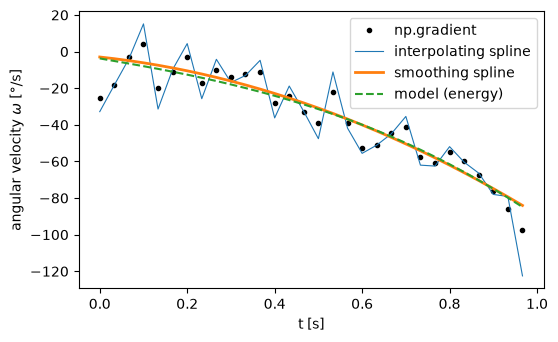

In [38]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(t_meas, np.degrees(omega_grad), "k.", label="np.gradient")
ax.plot(t_meas, np.degrees(omega_int), lw=0.8, label="interpolating spline")
ax.plot(t_meas, np.degrees(omega_smooth), lw=2, label="smoothing spline")
ax.plot(t_meas, np.degrees(omega_model), "--", label="model (energy)")
ax.set_xlabel("t [s]")
ax.set_ylabel("angular velocity $\\omega$ [°/s]")
ax.legend()
plt.show()

Plot of the angular acceleration.

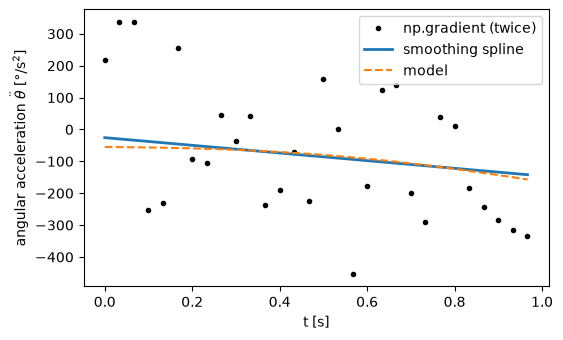

In [39]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(t_meas, np.degrees(alpha_grad), "k.", label="np.gradient (twice)")
ax.plot(t_meas, np.degrees(alpha_smooth), lw=2, label="smoothing spline")
ax.plot(t_meas, np.degrees(alpha_model), "--", label="model")
ax.set_xlabel("t [s]")
ax.set_ylabel("angular acceleration $\\ddot\\theta$ [°/s$^2$]")
ax.legend()
plt.show()

**Interpretation.** The scatter of `np.gradient` around the model (8°/s) is of the order of the expected amplified noise, the derivative of the interpolating spline is even worse at 14°/s, while the derivative of the smoothing spline (0.9°/s) follows the model, which approaches 85°/s at detachment. For the second derivative, differentiating numerically twice gives a scatter of about 190°/s$^2$, more than the signal itself (from $-55$ to $-157$°/s$^2$), the interpolating spline considerably more still, while the smoothing spline captures the acceleration with a scatter of about 10°/s$^2$ (at most about 30°/s$^2$ at the edges). Conclusion: from the video we can reliably determine the angular velocity, but the acceleration only approximately, and only because with the chosen $s$ the smoothing spline is a single cubic polynomial that describes the actual time history well; the result therefore depends strongly on $s$. For smooth data (e.g., the numerical solution of the equation of motion), `np.gradient` would be entirely adequate.

---

# Solving differential equations

## Frictionless fall of the ladder

We convert the equation of motion into a first-order system for the state $[\theta, \omega]$,

$$ \dot\theta = \omega, \qquad \dot\omega = -\frac{3g}{2L}\cos\theta, \qquad \theta(0) = \theta_0,\ \omega(0) = 0, $$

(`ld.ode_rhs`) and solve it with `scipy.integrate.solve_ivp`. Detachment from the wall is captured with an **event** (`events`): `ld.wall_force` returns $N_B$ from the current state, and the integration stops when $N_B$ passes through zero.

**Choice of method.** The problem is smooth, short, and **not stiff**, so the explicit RK45 method (Runge-Kutta 4(5) with adaptive step size) is the natural choice; implicit methods (`BDF`, `Radau`) would make sense only for a stiff system. We set the tolerances stricter than the defaults (`rtol=1e-8`) so that the comparison with energy and with the Euler method is not limited by the solver error. We verify the solution in three independent ways: the angular velocity with energy, the event time with the integral, and the event angle with the root of $N_B$.

In [40]:
def detachment(t, y, L, g):
    """Wall force from the state [theta, omega]; event when it passes through zero."""
    return ld.wall_force(y[0], y[1], m, L, g)


detachment.terminal = True      # the integration stops at the event
detachment.direction = -1       # only the transition from positive to negative N_B

Solving with RK45 until the detachment event.

In [41]:
solution_ode = solve_ivp(ld.ode_rhs, (0.0, 3.0), [theta0, 0.0],
                         args=(L, g), method="RK45", rtol=1e-8, atol=1e-10,
                         events=detachment, dense_output=True)
t_det_ode = solution_ode.t_events[0][0]
theta_det_ode, omega_det_ode = solution_ode.y_events[0][0]

Printing the results.

In [42]:
print(f"no. of steps: {solution_ode.t.size - 1}, evaluations: {solution_ode.nfev}")
print(f"event: t_det = {t_det_ode:.6f} s, "
      f"theta_det = {np.degrees(theta_det_ode):.4f}°")
print(f"omega at detachment = {np.degrees(omega_det_ode):.1f} °/s")

no. of steps: 22, evaluations: 134
event: t_det = 0.988220 s, theta_det = 40.0870°
omega at detachment = -88.2 °/s


Verification with energy, the integral, and the root of $N_B$.

In [43]:
t_dense = np.linspace(0.0, t_det_ode, 200)
theta_ode, omega_ode = solution_ode.sol(t_dense)
omega_en = ld.omega_energy(theta_ode, theta0, L, g)
diff_omega = np.abs(-omega_ode - omega_en).max()
print(f"largest difference in omega (solve_ivp - energy): "
      f"{diff_omega:.1e} rad/s")
print(f"t_det: event - quad = {t_det_ode - t_det_quad:.1e} s")
print(f"theta_det: event - brentq = "
      f"{np.degrees(theta_det_ode - theta_det_brent):.1e}°")

largest difference in omega (solve_ivp - energy): 6.0e-09 rad/s
t_det: event - quad = -1.7e-09 s
theta_det: event - brentq = 1.4e-08°


Plot of the angle over time and of the measurements from the video.

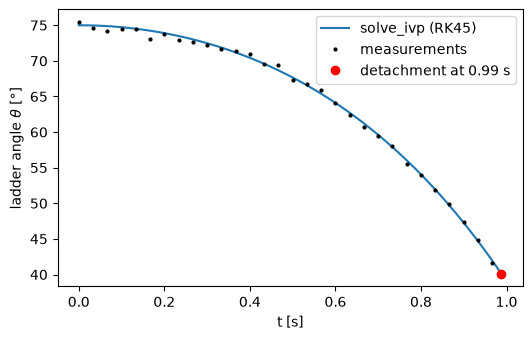

In [44]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(t_dense, np.degrees(theta_ode), label="solve_ivp (RK45)")
ax.plot(t_meas, np.degrees(theta_meas), "k.", ms=4, label="measurements")
ax.plot(t_det_ode, np.degrees(theta_det_ode), "ro",
        label=f"detachment at {t_det_ode:.2f} s")
ax.set_xlabel("t [s]")
ax.set_ylabel("ladder angle $\\theta$ [°]")
ax.legend()
plt.show()

**Interpretation.** The ladder detaches after 0.988 s at 40.1° with an angular velocity of 88°/s. The angular velocity from `solve_ivp` differs from the one from energy by less than $10^{-8}$ rad/s, the event time agrees with the integral to $10^{-9}$ s, and the event angle with the root to $10^{-8}$°; all three checks are independent. The measurements from the video lie on the solution within the noise (largest deviation about 1°), which, for synthetic measurements, confirms consistency, not the model. The slow start is physically meaningful: in the first half second, the angle changes by only a few degrees.

## Our own Euler method and the influence of the step size

For comparison, we wrote the explicit Euler method (`ld.euler`), the simplest first-order method, into the module. We compare the angle at $t = 0.9$ s (just before detachment) for steps from 0.05 s to 0.001 s; the reference is the `solve_ivp` solution. We expect the global error to decrease linearly with the step size; we estimate the order of the method from the slope on a logarithmic scale.

In [45]:
t_compare = 0.9
theta_ref = solution_ode.sol(t_compare)[0]
steps = np.array([0.05, 0.02, 0.01, 0.005, 0.002, 0.001])
errors_euler = np.zeros(steps.size)
for i, step in enumerate(steps):
    t_euler = np.arange(0.0, t_compare + step / 2, step)
    y_euler = ld.euler(ld.ode_rhs, [theta0, 0.0], t_euler, (L, g))
    errors_euler[i] = abs(y_euler[-1, 0] - theta_ref)
order_euler = np.polyfit(np.log(steps), np.log(errors_euler), 1)[0]

Printing the errors and the estimated order of the method.

In [46]:
for step, error in zip(steps, errors_euler):
    print(f"step {step:.3f} s: error {np.degrees(error):.3f}°")
print(f"estimated order of the method (slope in log-log): {order_euler:.2f}")

step 0.050 s: error 3.053°
step 0.020 s: error 1.284°
step 0.010 s: error 0.654°
step 0.005 s: error 0.330°
step 0.002 s: error 0.133°
step 0.001 s: error 0.066°
estimated order of the method (slope in log-log): 0.98


**Interpretation.** The error decreases linearly with the step size (estimated order 0.98), but even with a step of 1 ms (900 steps) it is still 0.07°, whereas `solve_ivp` with RK45 achieves an error below $10^{-6}$° with a few dozen steps, because it adapts the step size and has a higher order. For the computation, we therefore use `solve_ivp`; the Euler method is only a reference for understanding the order.

## Extension: friction on the floor

If the ladder slides on the floor with a coefficient of friction $\mu$, the force $F_A = \mu N_A$ opposes the motion of the lower end, and the reaction forces are no longer determined by energy. We write the Newton-Euler equations of a rigid body (two for the center of mass and the moment equation about the center of mass; the rotation angle of the body is $\pi - \theta$, so $-I_G\ddot\theta = \sum M_G$), which are **linear** in $\ddot\theta$, $N_A$, and $N_B$, and solve them with `sympy.solve`. At $\mu = 0$, the expression must agree with the equation of motion from the first chapter. The model is valid only if the ladder slips at all, i.e., if

$$ \mu < \frac{1}{2\tan\theta_0} \approx 0.13. $$

In [47]:
alpha = sym.symbols("alpha", real=True)
acc_x = -L_s / 2 * (sym.cos(theta) * omega**2 + sym.sin(theta) * alpha)
acc_y = L_s / 2 * (-sym.sin(theta) * omega**2 + sym.cos(theta) * alpha)
moment_G = L_s / 2 * (N_A * sym.cos(theta) - mu_s * N_A * sym.sin(theta)
                      - N_B * sym.sin(theta))
equations_ne = [sym.Eq(m_s * acc_x, N_B - mu_s * N_A),
                sym.Eq(m_s * acc_y, N_A - m_s * g_s),
                sym.Eq(-moment_of_inertia * alpha, moment_G)]
solution_ne = sym.solve(equations_ne, [alpha, N_A, N_B])

Angular acceleration with friction and numerical functions for solving.

In [48]:
display(sym.Eq(alpha, sym.simplify(solution_ne[alpha])))
print("at mu = 0:", sym.simplify(solution_ne[alpha].subs(mu_s, 0)))
alpha_friction = sym.lambdify((theta, omega, mu_s, L_s, g_s), solution_ne[alpha])
N_B_friction = sym.lambdify((theta, omega, mu_s, m_s, L_s, g_s),
                            solution_ne[N_B])

Eq(alpha, 6*(-L*mu*omega**2*sin(theta)**2 + 2*g*mu*sin(theta) - g*cos(theta))/(L*(-3*mu*sin(2*theta) + 4)))

at mu = 0: -3*g*cos(theta)/(2*L)


Right-hand side and event for the fall with friction $\mu = 0.1$.

In [49]:
mu_floor = 0.1


def rhs_friction(t, y, mu_floor):
    """First-order system for the fall with sliding on a floor with friction."""
    return [y[1], alpha_friction(y[0], y[1], mu_floor, L, g)]


def detachment_friction(t, y, mu_floor):
    """Wall force during the fall with friction; event at N_B = 0."""
    return N_B_friction(y[0], y[1], mu_floor, m, L, g)


detachment_friction.terminal = True
detachment_friction.direction = -1

Solving until detachment.

In [50]:
solution_friction = solve_ivp(rhs_friction, (0.0, 5.0), [theta0, 0.0],
                              args=(mu_floor,), rtol=1e-8, atol=1e-10,
                              events=detachment_friction, dense_output=True)
t_det_friction = solution_friction.t_events[0][0]
theta_det_friction = solution_friction.y_events[0][0, 0]
print(f"mu = {mu_floor}: t_det = {t_det_friction:.3f} s, "
      f"theta_det = {np.degrees(theta_det_friction):.1f}°")

mu = 0.1: t_det = 1.577 s, theta_det = 35.8°


Comparison of the fall without and with friction.

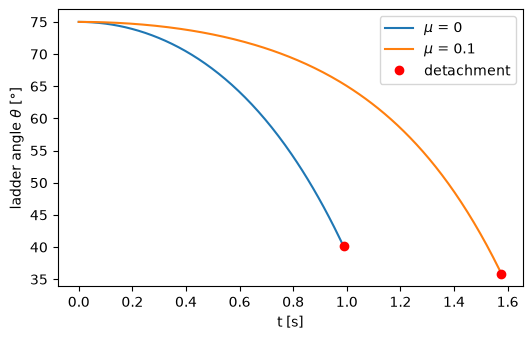

In [51]:
t_dense_friction = np.linspace(0.0, t_det_friction, 200)
theta_friction = solution_friction.sol(t_dense_friction)[0]
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(t_dense, np.degrees(theta_ode), label="$\\mu$ = 0")
ax.plot(t_dense_friction, np.degrees(theta_friction), label=f"$\\mu$ = {mu_floor}")
ax.plot([t_det_ode, t_det_friction],
        np.degrees([theta_det_ode, theta_det_friction]), "ro", label="detachment")
ax.set_xlabel("t [s]")
ax.set_ylabel("ladder angle $\\theta$ [°]")
ax.legend()
plt.show()

**Interpretation.** At $\mu = 0$, the symbolic solution reproduces $\ddot\theta = -\frac{3g}{2L}\cos\theta$, which confirms the signs in the moment equation. Friction $\mu = 0.1$ slows down the fall (1.58 s instead of 0.99 s until detachment) and shifts detachment to a smaller angle (35.8° instead of 40.1°), because friction takes away part of the energy. Whether the ladder slips at all must be determined by statics; the differential equation alone does not detect this.

## Animation of the fall

We show the frictionless fall until detachment with `matplotlib.animation.FuncAnimation`; the animation is embedded in HTML without additional packages.

In [52]:
t_frames = np.linspace(0.0, t_det_ode, 30)
frame_angles = solution_ode.sol(t_frames)[0]
fig, ax = plt.subplots(figsize=(3.4, 3.1), dpi=72)
ax.set_aspect("equal")
ax.plot([0, 0], [0, L], "k", lw=2)
ax.plot([0, L], [0, 0], "k", lw=2)
ladder_line, = ax.plot([], [], color="tab:brown", lw=4)
label_text = ax.text(2.0, 3.5, "")
ax.set_xlim(-0.2, L + 0.2)
ax.set_ylim(-0.2, L + 0.2)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
fig.tight_layout()


def update(i):
    ladder_line.set_data([L * np.cos(frame_angles[i]), 0.0],
                         [0.0, L * np.sin(frame_angles[i])])
    label_text.set_text(f"t = {t_frames[i]:.2f} s")
    return ladder_line, label_text


animation = FuncAnimation(fig, update, frames=t_frames.size, interval=60,
                          blit=True)
plt.close(fig)
HTML(animation.to_jshtml())

---

# Conclusion

Summary of the key results.

In [53]:
summary = pd.DataFrame({
    "quantity": ["coefficient of friction (curve_fit)",
                 "critical position of the person at 60° (brentq)",
                 "angle at which the whole ladder is safe",
                 "critical angle without a person (brentq)",
                 "detachment angle for a fall from 75°",
                 "time until detachment (quad / solve_ivp)",
                 "angular velocity at detachment",
                 "time until detachment at mu = 0.1"],
    "value": [f"{mu:.3f} ± {sigma_mu:.3f}",
              f"{x_cr_brent:.2f} m",
              f"{np.degrees(full_ladder_angle):.1f}°",
              f"{np.degrees(theta_cr_brent):.1f}°",
              f"{np.degrees(theta_det_ode):.1f}°",
              f"{t_det_quad:.3f} s / {t_det_ode:.3f} s",
              f"{np.degrees(abs(omega_det_ode)):.0f} °/s",
              f"{t_det_friction:.2f} s"],
})
summary

,quantity,value
0,coefficient of friction (curve_fit),0.323 ± 0.002
1,critical position of the person at 60° (brentq),2.27 m
2,angle at which the whole ladder is safe,70.9°
3,critical angle without a person (brentq),57.1°
4,detachment angle for a fall from 75°,40.1°
5,time until detachment (quad / solve_ivp),0.988 s / 0.988 s
6,angular velocity at detachment,88 °/s
7,time until detachment at mu = 0.1,1.58 s


**Key results.** With the measured $\mu = 0.323$, a person (80 kg) can safely climb a ladder at an angle of 60° only up to **2.27 m** of 4 m; the whole ladder is safe only at angles above **71°**, and without a person the ladder slips below **57°**, which is consistent with the 4 : 1 rule (75°) [3]. On a smooth floor, a ladder released at 75° reaches **40°** after **0.99 s**, where it detaches from the wall with an angular velocity of 88°/s; friction $\mu = 0.1$ slows the fall to 1.6 s. The results are physically meaningful: the reactions grow linearly with the position of the person, the detachment angle is independent of mass and length, and the fall from a steep position starts slowly.

**Verification.** Each method is verified in an independent way where it is used: symbolic expressions with the module functions, and the LU decomposition with `np.linalg.solve` and with the symbolic solution (`np.testing`), `brentq` and Newton's method with analytical expressions, `quad` and the root of $N_B$ with the event in `solve_ivp`, `solve_ivp` with conservation of energy, the Euler method with `solve_ivp`, and the model with friction at $\mu = 0$ with the frictionless model. We did not write formal unit tests for the module.

**Limitations.**
* The measurements are synthetic; agreement with the model demonstrates the consistency of the procedure, not the correctness of the model.
* The uncertainty of $\mu$ ($\pm 0.002$) is not propagated to $x_{cr}$ and $\theta_{cr}$, although, owing to linearity, the estimate would be simple.
* From a video at 30 frames per second, we can reliably determine the angular velocity, but the acceleration only approximately; the smoothing parameter $s$ is determined from the noise estimate, and its influence on the derivatives has not been checked.
* The model of the fall is valid only until detachment; the subsequent motion and the impact on the floor would require additional degrees of freedom and an impact model.

**Possible improvements.** Real measurements with an actual ladder and a faster camera; propagation of the uncertainty of $\mu$ to the critical position; comparison of solvers (`DOP853`, `Radau`) and tolerances; a model of the motion after detachment. Additional "extra" content.

---

# Use of artificial intelligence

I used Claude (chat in the browser) and GitHub Copilot in VS Code.

* **For what:** explanations of Brent's method and of events (`events`) in `solve_ivp`, help with deriving the equation of motion with friction in `sympy`, writing docstrings and plotting functions, reviewing the text of the report.
* **Where the AI was wrong:** for the time to detachment, it suggested the trapezoidal rule; because the integrand has a singularity at the limit, the error decreases too slowly (chapter *Integration / differentiation*), so I used `quad`. For differentiating the angle from the video, it suggested an interpolating spline, whose derivative strongly amplifies the noise; I chose the smoothing spline after comparing with the model. The suggested moment equation with friction had a wrong sign, which I noticed because at $\mu = 0$ the solution did not match the frictionless equation.
* **What I did myself:** the choice of the problem and the model, the sketch, the choice of methods, all verifications (analytical solutions, energy, comparison of methods), and the interpretation of the results.

---

# Sources

1. G. Čepon, M. Pogačar, M. Kodrič: *Statika in kinematika* [Statics and Kinematics], UL Faculty of Mechanical Engineering, Ljubljana, 2023 (equilibrium of a rigid body, friction).
2. J. Slavič: *Dinamika, mehanska nihanja in mehanika tekočin* [Dynamics, Mechanical Vibrations and Fluid Mechanics], 2nd edition, Faculty of Mechanical Engineering, Ljubljana, 2017 (Chapter 2.4: Kinetics of rigid bodies, Section 2.4.2: Planar motion of a rigid body).
3. Health and Safety Executive (UK): *Safe use of ladders and stepladders: A brief guide*, INDG455, 2014 (ladder angle 75°, 1 in 4 rule).
4. J. Slavič: *Numerical Methods in the Python Ecosystem*, Faculty of Mechanical Engineering, University of Ljubljana (lectures of the course Numerical Methods).
5. SciPy documentation: `scipy.linalg`, `scipy.interpolate`, `scipy.optimize`, `scipy.integrate`, https://docs.scipy.org/doc/scipy/.